In [112]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import math
import numpy as np

In [113]:
# Load Qualtrics export
df = pd.read_csv("./data.csv", skiprows=[1, 2])

# Load mapping file
mapping = pd.read_csv(
    "./Stimuli_Question_Mapping.csv"
)
df

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,Q30,Q31,Q32,Q33,Q34,Q35,id,FL_12_DO,FL_82_DO,FL_75_DO
0,2026-01-14 14:38:23,2026-01-14 15:05:14,0,69.180.30.89,100,1611,1,2026-01-14 15:05:15,R_7Fg1XuwBBdNO5lH,NaN,...,7.0,3.0,5.0,6.0,4.0,6.0,27887.0,4_105_O|BL_5sSwQRauKEyO4yW|4_35_O|BL_ewyaGNFry...,NaN,Repetition_1_25_O|Repetition_2_40_S|Repetition...
1,2026-01-19 11:51:55,2026-01-19 12:46:44,0,24.30.48.111,100,3289,1,2026-01-19 12:46:45,R_6efcBElj6FCvBmV,NaN,...,6.0,5.0,7.0,7.0,4.0,3.0,27887.0,3_7_S|2_40_S|BL_3dY4ihmtQDZXivQ|BL_7O6w7E48efN...,NaN,Repetition_1_25_O|Repetition_4_35_O|Repetition...
2,2026-01-19 13:55:09,2026-01-19 14:21:09,0,69.180.30.89,100,1560,1,2026-01-19 14:21:10,R_75rcpr2IJ8FQlt7,NaN,...,7.0,3.0,5.0,6.0,4.0,3.0,27887.0,3_16_S|1_21_S|3_15_O|4_49_S|4_105_O|2_70_S|3_2...,4_35_S|2_14_S|2_70_O|3_25_O|2_20_S|2_40_O|4_31...,Repetition_1_25_O|Repetition_3_16_S|Repetition...
3,2026-01-20 19:31:48,2026-01-20 20:03:34,0,128.61.160.141,100,1906,1,2026-01-20 20:03:35,R_6ONTIhMg73HcsJO,NaN,...,3.0,1.0,1.0,5.0,1.0,2.0,28100.0,3_25_S|2_14_O|4_49_S|3_7_O|1_21_S|3_16_S|3_7_S...,4_49_O|1_18_S|1_21_O|2_14_S|1_29_O|2_70_O|4_35...,Repetition_2_40_S|Repetition_1_25_O|Repetition...
4,2026-01-20 21:09:51,2026-01-20 22:55:56,0,136.55.59.237,100,6364,1,2026-01-20 22:55:57,R_7PLFHJcP1sCHknL,NaN,...,5.0,3.0,5.0,6.0,2.0,2.0,28048.0,1_18_O|3_15_O|1_25_O|3_16_S|2_20_O|3_7_S|4_105...,1_29_O|4_49_O|1_21_O|2_70_O|3_25_O|1_18_S|1_25...,Repetition_2_40_S|Repetition_3_16_S|Repetition...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,2026-03-24 11:02:18,2026-03-24 11:02:24,0,216.237.197.206,1,5,0,2026-03-31 11:02:28,R_58M0RhQWP5ModkC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,79538.0,NaN,NaN,NaN
143,2026-03-24 10:43:01,2026-03-24 11:02:45,0,216.237.197.206,18,1184,0,2026-03-31 11:02:53,R_5KURmxv0WlJEAPn,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,79537.0,3_16_S|3_15_O|4_105_S|2_70_S|1_29_S|1_18_O|2_2...,NaN,NaN
144,2026-03-27 13:27:53,2026-03-27 13:34:18,0,12.156.26.183,18,385,0,2026-04-03 13:34:20,R_17JTC7vawhX7PCV,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,66304.0,1_25_O|4_49_S|3_15_O|2_70_S|3_7_O|2_20_O|3_16_...,NaN,NaN
145,2026-03-30 21:41:45,2026-03-30 21:42:14,0,128.61.160.48,3,28,0,2026-04-06 21:42:15,R_7MoIkUHZbFb7iff,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,61213.0,NaN,NaN,NaN


# Pre-Processing

In [114]:
response_ids = [rid for rid in df["ResponseId"].tolist() if rid.startswith("R_")]
print(f"{len(response_ids)} responses: {response_ids[0:5]}...")


147 responses: ['R_7Fg1XuwBBdNO5lH', 'R_6efcBElj6FCvBmV', 'R_75rcpr2IJ8FQlt7', 'R_6ONTIhMg73HcsJO', 'R_7PLFHJcP1sCHknL']...


## Pre-processing: continuous ratings

In [115]:
def parse_stimulus_name(name):
    # (re)<quadrant>_<seq_id>_<version>(_overall)
    if name.startswith("re"):
        name = name[2:]  # strip repeat prefix if needed
    if name.endswith("_overall"):
        quad, seq, version, _ = name.split("_")
    else: 
        quad, seq, version = name.split("_")
    return int(quad), int(seq), version

mapping[["quadrant", "sequence_id", "version"]] = (
    mapping["Data"]
    .apply(parse_stimulus_name)
    .apply(pd.Series)
)

# Filter continuous-rating questions only (not overall)
mapping = mapping[~mapping["Data"].str.contains("overall")]
mapping

,Data,QualtricsID,HarmonicFunction,quadrant,sequence_id,version
0,1_21_S,Q143,same,1,21,S
2,1_25_O,Q147,same,1,25,O
4,1_18_O,Q159,diff,1,18,O
6,1_29_S,Q171,diff,1,29,S
8,2_14_O,Q175,same,2,14,O
10,2_70_S,Q187,same,2,70,S
12,2_20_O,Q191,diff,2,20,O
14,2_40_S,Q203,diff,2,40,S
16,3_15_O,Q207,same,3,15,O
18,3_16_S,Q219,same,3,16,S


In [116]:
df[df["ResponseId"]=="R_7Fg1XuwBBdNO5lH"]["Q143"].iloc[0]

'[{"time":0.198318,"value":""},{"time":0.45992,"value":""},{"time":0.714685,"value":""},{"time":0.986945,"value":""},{"time":1.260107,"value":""},{"time":1.538064,"value":""},{"time":1.794595,"value":""},{"time":2.053955,"value":""},{"time":2.31743,"value":""},{"time":2.577142,"value":""},{"time":2.852424,"value":""},{"time":3.128478,"value":""},{"time":3.39147,"value":""},{"time":3.6502,"value":""},{"time":3.908868,"value":""},{"time":4.169552,"value":""},{"time":4.433961,"value":""},{"time":4.715413,"value":""},{"time":4.974244,"value":""},{"time":5.235378,"value":""},{"time":5.49918,"value":""},{"time":5.760337,"value":""},{"time":6.032839,"value":""},{"time":6.312465,"value":""},{"time":6.573504,"value":""},{"time":6.832598,"value":""},{"time":7.094718,"value":""},{"time":7.357378,"value":""},{"time":7.635007,"value":""},{"time":7.913623,"value":""},{"time":8.174924,"value":""},{"time":8.433572,"value":""},{"time":8.69123,"value":""},{"time":8.948756,"value":""},{"time":9.213875,"v

In [117]:
CHORD_DURATION = 2.4
N_CHORDS = 11
COUNTDOWN_TIME = 2 * CHORD_DURATION

records = []

for _, row in mapping.iterrows():
    qid = row["QualtricsID"]
    stim = row["Data"]

    if qid not in df.columns:
        continue

    for rid in response_ids:
        trace = df[df["ResponseId"]==rid][qid].iloc[0]
        try:
            points = json.loads(trace)
        except Exception:
            continue

        for p in points:
            records.append({
                "response": rid,
                "trial_id": stim,
                "quadrant": row["quadrant"],
                "sequence_id": row["sequence_id"],
                "version": row["version"],  # O or S
                "time": p["time"],
                "chord_index": int((p["time"]-COUNTDOWN_TIME) // CHORD_DURATION),
                "pleasantness_rating": float(p["value"]) if p["value"] else np.nan
            })

continuous_ratings = pd.DataFrame(records)
continuous_ratings = continuous_ratings[continuous_ratings.chord_index < N_CHORDS]
continuous_ratings.to_csv("./continuous_ratings.csv", index=False)

continuous_ratings


,response,trial_id,quadrant,sequence_id,version,time,chord_index,pleasantness_rating
0,R_7Fg1XuwBBdNO5lH,1_21_S,1,21,S,0.198318,-2,NaN
1,R_7Fg1XuwBBdNO5lH,1_21_S,1,21,S,0.459920,-2,NaN
2,R_7Fg1XuwBBdNO5lH,1_21_S,1,21,S,0.714685,-2,NaN
3,R_7Fg1XuwBBdNO5lH,1_21_S,1,21,S,0.986945,-2,NaN
4,R_7Fg1XuwBBdNO5lH,1_21_S,1,21,S,1.260107,-2,NaN
...,...,...,...,...,...,...,...,...
514165,R_6gz8jeGkaIWjWUh,re4_35_O,4,35,O,29.943258,10,-20.0
514166,R_6gz8jeGkaIWjWUh,re4_35_O,4,35,O,30.208639,10,-20.0
514167,R_6gz8jeGkaIWjWUh,re4_35_O,4,35,O,30.475168,10,-20.0
514168,R_6gz8jeGkaIWjWUh,re4_35_O,4,35,O,30.740398,10,-20.0


## Pre-processing: Exclusion

### Late Start

Participant likley zoned out if they didn't start rating until after a few chords

In [126]:
START_RATING_THRESHOLD = 3 # 0-indexed

start_stats = (
    continuous_ratings
    .groupby(["response", "trial_id"])
    .apply(lambda d: pd.Series({
        "first_rating_time": d.loc[
            d.pleasantness_rating.notna(), "time"
        ].min(),
        "first_rating_chord": d.loc[
            d.pleasantness_rating.notna(), "chord_index"
        ].min()
    }))
    .reset_index()
)

late_start = start_stats[
    (start_stats["first_rating_chord"] >= START_RATING_THRESHOLD) |
    (start_stats["first_rating_chord"].isna())  # never rated at all
]
# late_start['response'].nunique()
late_start

/var/folders/z2/2l9p7g8n0jjb9kjwgl6q8slw0000gn/T/ipykernel_75847/1258725164.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({


,response,trial_id,first_rating_time,first_rating_chord
46,R_1466hO0Z03hgUhq,3_16_O,14.449278,4.0
49,R_1466hO0Z03hgUhq,3_25_S,16.171548,4.0
55,R_1466hO0Z03hgUhq,4_35_O,13.596163,3.0
57,R_15UXjOTvKwni6eR,1_18_O,19.332887,6.0
58,R_15UXjOTvKwni6eR,1_18_S,14.284911,3.0
...,...,...,...,...
4203,R_7rHfkVNs7QHbLag,2_40_S,NaN,NaN
4207,R_7rHfkVNs7QHbLag,3_15_S,NaN,NaN
4212,R_7rHfkVNs7QHbLag,3_7_O,NaN,NaN
4213,R_7rHfkVNs7QHbLag,3_7_S,NaN,NaN


### Long Inactivity
Participant likely zoned out if they didn't move slider for longer than the threshold


In [85]:
INACTIVITY_THRESHOLD = CHORD_DURATION*5

def extract_long_inactivities(d, min_duration):
    """
    d: data for one trial_id
    min_duration: duration threshold (seconds)
    """
    d = (
        d
        .dropna(subset=["pleasantness_rating"])
        .sort_values("time")
        .reset_index(drop=True)
    )

    if len(d) < 2:
        return []

    # Start a new segment whenever the value changes
    segment_id = (d.pleasantness_rating != d.pleasantness_rating.shift()).cumsum()
    d["segment_id"] = segment_id

    inactivities = (
        d.groupby("segment_id")
        .agg(
            value=("pleasantness_rating", "first"),
            start_time=("time", "first"),
            end_time=("time", "last")
        )
        .reset_index(drop=True)
    )

    inactivities["duration"] = inactivities["end_time"] - inactivities["start_time"]

    # Keep only long inactivities
    inactivities = inactivities[inactivities["duration"] >= min_duration]

    return inactivities

all_inactivities = []

for (response, trial_id), d in continuous_ratings.groupby(
    ["response", "trial_id"]
):
    inactivities = extract_long_inactivities(d, min_duration=INACTIVITY_THRESHOLD)
    if len(inactivities) == 0:
        continue

    inactivities["response"] = response
    inactivities["trial_id"] = trial_id
    all_inactivities.append(inactivities)

long_inactivities = pd.concat(all_inactivities, ignore_index=True)

long_inactivities

,value,start_time,end_time,duration,response,trial_id
0,30.0,13.585465,31.141937,17.556472,R_1466hO0Z03hgUhq,1_21_S
1,76.0,13.247536,31.112130,17.864594,R_1466hO0Z03hgUhq,3_15_O
2,77.0,18.670685,31.155388,12.484703,R_1466hO0Z03hgUhq,4_35_O
3,-15.0,8.742485,31.142195,22.399710,R_15UXjOTvKwni6eR,1_25_O
4,-30.0,11.942788,31.085594,19.142806,R_15UXjOTvKwni6eR,1_25_S
...,...,...,...,...,...,...
834,-50.0,18.816888,31.084243,12.267355,R_7rwXPXtG1YFPvVJ,3_25_S
835,12.0,6.571298,28.671299,22.100001,R_7rwXPXtG1YFPvVJ,3_7_S
836,17.0,11.881568,30.765793,18.884225,R_7wp3WmD3UFSKp9M,3_7_O
837,15.0,7.118179,20.414286,13.296107,R_7wp3WmD3UFSKp9M,3_7_S


### Rapid Jumps
Participants who repeatedly moved the slider between extreme values are unlikely to be providing stimulus-driven ratings.


In [130]:
import pandas as pd
import numpy as np

# Parameters
RATING_MIN = -100
RATING_MAX = 100
# == THRESHOLD DEFINITION ==
THRESHOLD = 0.5 * (RATING_MAX - RATING_MIN)
NUM_JUMPS_THRESHOLD = 3
# ==========================

jump_summary = []

for (response, trial_id), d in continuous_ratings.groupby(["response", "trial_id"]):
    d = (
        d.dropna(subset=["pleasantness_rating"])
         .sort_values("time")
         .reset_index(drop=True)
    )

    if len(d) < 2:
        continue

    value_before = d["pleasantness_rating"].iloc[:-1].values
    value_after = d["pleasantness_rating"].iloc[1:].values
    time_before = d["time"].iloc[:-1].values
    time_after = d["time"].iloc[1:].values

    jump_sizes = (value_after - value_before).astype(float)
    abs_jump_sizes = np.abs(jump_sizes)

    large_jump_mask = abs_jump_sizes >= THRESHOLD

    # Collect large jumps
    large_jumps = [
        {
            "time_before": tb,
            "time_after": ta,
            "value_before": vb,
            "value_after": va
        }
        for tb, ta, vb, va, mask in zip(
            time_before, time_after, value_before, value_after, large_jump_mask
        )
        if mask
    ]

    if len(large_jumps) < NUM_JUMPS_THRESHOLD:
        continue

    # --- ≥3 jumps within CHORD_DURATION ---
    jump_times = np.array([j["time_after"] for j in large_jumps])

    has_cluster = False
    for i in range(len(jump_times)):
        window_start = jump_times[i]
        window_end = window_start + CHORD_DURATION
        n_in_window = np.sum(
            (jump_times >= window_start) & (jump_times <= window_end)
        )
        if n_in_window >= NUM_JUMPS_THRESHOLD:
            has_cluster = True
            break

    if has_cluster:
        jump_summary.append({
            "response": response,
            "trial_id": trial_id,
            "large_jumps": large_jumps
        })

rapid_jumps = pd.DataFrame(jump_summary)
rapid_jumps


,response,trial_id,large_jumps
0,R_1CTxS1cABIi6avT,1_29_S,"[{'time_before': 3.6903960079952514, 'time_aft..."
1,R_39bn3d5gFOxzYMr,2_40_O,"[{'time_before': 17.215673, 'time_after': 17.4..."
2,R_5ib6q2Swb0efZFF,2_40_O,"[{'time_before': 2.564013, 'time_after': 2.828..."
3,R_5ib6q2Swb0efZFF,4_105_S,"[{'time_before': 9.734662, 'time_after': 9.999..."
4,R_7rwXPXtG1YFPvVJ,3_15_O,"[{'time_before': 3.36049, 'time_after': 3.6244..."


In [131]:
rapid_jumps.loc[0, "large_jumps"]

[{'time_before': 3.6903960079952514,
  'time_after': 3.9404603190014846,
  'value_before': -69.0,
  'value_after': 60.0},
 {'time_before': 3.9404603190014846,
  'time_after': 4.191042649001525,
  'value_before': 60.0,
  'value_after': -65.0},
 {'time_before': 4.191042649001525,
  'time_after': 4.441280079000851,
  'value_before': -65.0,
  'value_after': 58.0}]

### Exclusions (Stimuli-level & participant-level)

In [132]:
invalid_trials = (
    pd.concat([
        late_start[["response", "trial_id"]],
        # hard to tell if long inactivities is due to zoning out or real consistent ratings
        # long_inactivities[["response", "trial_id"]],
        rapid_jumps[["response", "trial_id"]]
    ], ignore_index=True)
    .drop_duplicates()
)
invalid_trials

,response,trial_id
0,R_1466hO0Z03hgUhq,3_16_O
1,R_1466hO0Z03hgUhq,3_25_S
2,R_1466hO0Z03hgUhq,4_35_O
3,R_15UXjOTvKwni6eR,1_18_O
4,R_15UXjOTvKwni6eR,1_18_S
...,...,...
938,R_7rwXPXtG1YFPvVJ,2_70_S
939,R_1CTxS1cABIi6avT,1_29_S
941,R_5ib6q2Swb0efZFF,2_40_O
942,R_5ib6q2Swb0efZFF,4_105_S


In [133]:
TOTAL_TRIALS = 36
INVALID_FRACTION_THRESHOLD = 1 / 2

suspicious_participants = (
    pd.concat([
        late_start[["response", "trial_id"]],
        # hard to tell if long inactivities is due to zoning out or real consistent ratings
        # but if a participant keeps doing this across stimuli, they may be zoning out.
        # long_inactivities[["response", "trial_id"]],
        rapid_jumps[["response", "trial_id"]]
    ], ignore_index=True)
    .drop_duplicates()
)

invalid_counts = (
    suspicious_participants
    .groupby("response")
    .size()
    .reset_index(name="n_invalid_trials")
)

invalid_counts["invalid_fraction"] = (
    invalid_counts["n_invalid_trials"] / TOTAL_TRIALS
)

invalid_participants = invalid_counts[
    invalid_counts["invalid_fraction"] > INVALID_FRACTION_THRESHOLD
]

invalid_counts.sort_values("n_invalid_trials", ascending=False)

,response,n_invalid_trials,invalid_fraction
61,R_6NqO4WFbhWHKrvH,35,0.972222
30,R_3s5b9brLHtE9QFy,34,0.944444
26,R_3fDP90uQ58KY4QX,32,0.888889
43,R_5NvSLhn6e1uQHlL,32,0.888889
50,R_5h4oqjOIPXgQzxH,32,0.888889
...,...,...,...
13,R_342jRMCUa8BrKAF,1,0.027778
60,R_6H2jlOOKQy6Bdux,1,0.027778
9,R_1cTk4JpFTveIkoz,1,0.027778
54,R_5xIPzVntMqAeUQ9,1,0.027778


In [110]:
df[df["Finished"] != 1].to_csv("./unfinished.csv", index=False)


In [134]:
# did_not_finish = df[df["Finished"].astype(int) != 1]["ResponseId"].tolist()
# print(len(set(did_not_finish)))

# Exclude participants (all trials from invalid participants)
# did_not_finish = df[df["Finished"] != 1]["ResponseId"].tolist()
# print("Participants who didn't finish:", len(set(did_not_finish)))

invalid_response_ids = (
    invalid_participants["response"].tolist()
    # + did_not_finish
)
ratings_valid_participants = continuous_ratings[
    ~continuous_ratings["response"].isin(invalid_response_ids)
].copy()

print("Participants removed:", len(invalid_response_ids))


# Exclude trials 
# (paired trials - that participant's ratings for both Original and Swap sequence)
def paired_trial_id(trial_id):
    if trial_id.startswith("re"):
        return None
    if trial_id.endswith("_S"):
        return trial_id[:-2] + "_O"
    if trial_id.endswith("_O"):
        return trial_id[:-2] + "_S"
    return None

# raw invalid trials
invalid_trials_valid_participants = (
    invalid_trials[
        ~invalid_trials["response"].isin(invalid_response_ids)
    ]
    .copy()
)

# also include paired versions of the invalid trials (Swap / Original)
paired_rows = []
for _, row in invalid_trials_valid_participants.iterrows():
    paired_id = paired_trial_id(row["trial_id"])
    if paired_id is not None:
        paired_rows.append({
            "response": row["response"],
            "trial_id": paired_id
        })
paired_invalid_trials = pd.DataFrame(paired_rows)
expanded_invalid_trials = (
    pd.concat(
        [invalid_trials_valid_participants, paired_invalid_trials],
        ignore_index=True
    )
    .drop_duplicates()
)

print("Trials removed from valid participants:", expanded_invalid_trials.shape[0])


clean_continuous_ratings = (
    ratings_valid_participants
    .merge(
        expanded_invalid_trials.assign(invalid_trial=True),
        on=["response", "trial_id"],
        how="left"
    )
)
clean_continuous_ratings = clean_continuous_ratings[
    clean_continuous_ratings["invalid_trial"].isna()
].drop(columns="invalid_trial")

# No invalid participants remain
assert not clean_continuous_ratings["response"].isin(invalid_response_ids).any()
# No invalid trials remain
remaining_invalid = clean_continuous_ratings.merge(
    expanded_invalid_trials,
    on=["response", "trial_id"],
    how="inner"
)
assert len(remaining_invalid) == 0
clean_continuous_ratings.to_csv("./clean_continuous_ratings.csv", index=False)


Participants removed: 23
Trials removed from valid participants: 535


In [135]:
# If some analysis doesn't rely on paired comparison, they can use this one for more data.
clean_continuous_ratings_keep_paired = (
    ratings_valid_participants
    .merge(
        invalid_trials_valid_participants.assign(invalid_trial=True),
        on=["response", "trial_id"],
        how="left"
    )
)
clean_continuous_ratings_keep_paired = clean_continuous_ratings_keep_paired[
    clean_continuous_ratings_keep_paired["invalid_trial"].isna()
].drop(columns="invalid_trial")
clean_continuous_ratings_keep_paired.to_csv("./clean_continuous_ratings_keep_paired.csv", index=False)



## Participant analysis

In [ ]:
"""
post_exclusion_participant_stats.py
------------------------------------

Computes demographic and questionnaire stats for the participants and trials
that are actually retained in the analysis.
"""

import pandas as pd
import numpy as np

# ── Load raw Qualtrics data & filter to valid participants ────────────────────
df_raw = pd.read_csv("./data.csv", skiprows=[1, 2])

# `invalid_response_ids` is already defined by exclusion block
key_cols = ["Q23", "Q24", "Q26_1", "Q27_1", "Q28"]
df_valid = df_raw[
    ~df_raw["ResponseId"].isin(invalid_response_ids) &
    df_raw[key_cols].notna().all(axis=1)
].copy()
N = len(df_valid)
print(f"Participants excluded from attention criteria: {len(invalid_response_ids)}\n")
print(f"Participants retained who had demographic and survey data: N = {N}")

# ── Report excluded trial counts ──────────────────────────────────────────────
# `expanded_invalid_trials` is already defined by exclusion block
n_excluded_trials = len(expanded_invalid_trials)
print(f"Trials excluded from valid participants: {n_excluded_trials}\n")

# ── Gender (Q24) ──────────────────────────────────────────────────────────────
# 1 = Male, 2 = Female, 3 = Non-binary, 4 = Prefer not to say
gender    = pd.to_numeric(df_valid["Q24"], errors="coerce")
n_female  = (gender == 2).sum()
n_male    = (gender == 1).sum()
n_nb      = (gender == 3).sum()
n_pnts    = (gender == 4).sum()
print(f"Gender: {n_female} female, {n_male} male, {n_nb} non-binary, {n_pnts} undisclosed\n")

# ── Age (Q23) ─────────────────────────────────────────────────────────────────
age      = pd.to_numeric(df_valid["Q23"], errors="coerce")
age_mean = age.mean()
age_sd   = age.std(ddof=1)
print(f"Age: M = {age_mean:.1f} y, SD = {age_sd:.2f}\n")

# ── BMRQ (Q26_1–Q26_20) ──────────────────────────────────────────────────────
# 5-point Likert; items 2 and 5 reverse-scored (6 − raw)
bmrq_cols = [f"Q26_{i}" for i in range(1, 21)]
bmrq      = df_valid[bmrq_cols].apply(pd.to_numeric, errors="coerce").copy()
for col in ["Q26_2", "Q26_5"]:
    bmrq[col] = 6 - bmrq[col]
bmrq_total = bmrq.sum(axis=1)
bmrq_mean  = bmrq_total.mean()
bmrq_sd    = bmrq_total.std(ddof=1)
print(f"BMRQ total (range 20–100): M = {bmrq_mean:.1f}, SD = {bmrq_sd:.2f}\n")

# ── Gold-MSI General Sophistication (18-item subscale from Q27) ───────────────
# 7-point Likert; negatively worded items reversed (8 − raw)
# Reverse positions in full 38-item scale: 4, 9, 12, 14, 17, 21, 26
goldmsi_cols = [f"Q27_{i}" for i in [1, 3, 4, 7, 10, 12, 14, 15, 17, 19, 23, 24, 25, 27, 29, 32, 33, 37]]
goldmsi      = df_valid[goldmsi_cols].apply(pd.to_numeric, errors="coerce").copy()
for pos in [14, 17, 23, 25, 27]:
    col = f"Q27_{pos}"
    if col in goldmsi.columns:
        goldmsi[col] = 8 - goldmsi[col]

# General Sophistication subscale: items at full-scale positions 3–16, 18, 21, 24, 25
gen_items = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 21, 24, 25]
gen_cols  = [f"Q27_{i}" for i in gen_items if i <= 31]
gen_scale = goldmsi[gen_cols].sum(axis=1)
gen_mean  = gen_scale.mean()
gen_sd    = gen_scale.std(ddof=1)
print(f"Gold-MSI General Sophistication (18-item, range 18–126): M = {gen_mean:.1f}, SD = {gen_sd:.2f}\n")

# ── Gold-MSI Musical Training subscale (Q28, Q30–Q35) ────────────────────────
# 7-point ordered categories per instrument; total range 7–49
mt_cols  = ["Q28", "Q30", "Q31", "Q32", "Q33", "Q34", "Q35"]
mt       = df_valid[mt_cols].apply(pd.to_numeric, errors="coerce")
mt_total = mt.sum(axis=1)
mt_mean  = mt_total.mean()
mt_sd    = mt_total.std(ddof=1)
mt_min   = mt_total.min()
mt_max   = mt_total.max()
print(f"Gold-MSI Musical Training (7 items, range 7–49): M = {mt_mean:.1f}, SD = {mt_sd:.2f}, range = {mt_min:.0f}–{mt_max:.0f}\n")

# ── Save relevant columns to CSV for inspection ───────────────────────────────
cols_to_save = (
    ["ResponseId", "Q23", "Q24"]
    + [f"Q26_{i}" for i in range(1, 21)]
    + [f"Q27_{i}" for i in range(1, 32)]
    + ["Q28", "Q30", "Q31", "Q32", "Q33", "Q34", "Q35"]
)

# Add scored columns for easy checking
df_inspect = df_valid[cols_to_save].copy()
df_inspect["age"]          = pd.to_numeric(df_inspect["Q23"], errors="coerce")
df_inspect["gender"]       = pd.to_numeric(df_inspect["Q24"], errors="coerce")
df_inspect["bmrq_total"]   = bmrq_total.values
df_inspect["goldmsi_gen"]  = gen_scale.values
df_inspect["goldmsi_mt"]   = mt_total.values

df_inspect.to_csv("./participant_questionnaire_data.csv", index=False)
print("Saved: participant_questionnaire_data.csv")

Participants excluded from attention criteria: 23

Participants retained who had demographic and survey data: N = 91
Trials excluded from valid participants: 535

Gender: 55 female, 34 male, 1 non-binary, 1 undisclosed

Age: M = 19.8 y, SD = 1.71

BMRQ total (range 20–100): M = 76.9, SD = 11.97

Gold-MSI General Sophistication (18-item, range 18–126): M = 78.7, SD = 9.78

Gold-MSI Musical Training (7 items, range 7–49): M = 24.2, SD = 8.58, range = 8–44

Saved: participant_questionnaire_data.csv


### Overall rating per trial as covariate

In [105]:
# --- 1. Recreate overall mapping ---
mapping_full = pd.read_csv("./Stimuli_Question_Mapping.csv")

mapping_full[["quadrant", "sequence_id", "version"]] = (
    mapping_full["Data"]
    .apply(parse_stimulus_name)
    .apply(pd.Series)
)

overall_mapping = (
    mapping_full[mapping_full["Data"].str.endswith("_overall")]
    .assign(trial_id=lambda d: d["Data"].str.replace("_overall", "", regex=False))
)
overall_mapping


# --- 2. Keep valid participants only ---
df_valid = df[~df["ResponseId"].isin(invalid_response_ids)]

# --- 3. Extract + reshape overall ratings ---
overall_long = (
    df_valid
    .melt(
        id_vars="ResponseId",
        value_vars=overall_mapping["QualtricsID"],
        var_name="QualtricsID",
        value_name="overall_pleasantness"
    )
    .merge(
        overall_mapping[["trial_id", "QualtricsID"]],
        on="QualtricsID",
        how="left"
    )
    .rename(columns={"ResponseId": "response"})
)

overall_long["overall_pleasantness"] = pd.to_numeric(
    overall_long["overall_pleasantness"],
    errors="coerce"
)

overall_long = overall_long.dropna(subset=["overall_pleasantness"])

# --- 4. Remove invalid trials (same logic as before) ---
overall_long = (
    overall_long
    .merge(
        expanded_invalid_trials.assign(invalid_trial=True),
        on=["response", "trial_id"],
        how="left"
    )
)

overall_long = overall_long[overall_long["invalid_trial"].isna()]


# --- 6. Save ---
overall_long.to_csv("overall_ratings.csv", index=False)

## Other Preprocessing Steps

### Smoothing (Moving Median Filter)

Cheung et al. (2019):
> To obtain pleasure ratings for all chords, the pleasantness time series for every chord progression was first smoothed using a moving median filter with a fifth-order symmetric window to reduce analog noise.

> The mode of the smoothed signal was then sampled in a time window from one second after each chord onset until its end to account for delays in moving the slider. 

----


> The first chord of each progression was discarded since each trial began by resetting the slider.

We don't exclude first chord because we have the countdown and automatic slider reset.

In [106]:
from scipy.signal import medfilt

REACTION_DELAY = 1.0 # seconds
MEDIAN_KERNEL_SIZE = 5  # fifth-order symmetric window


def smooth_trial(d, kernel_size=5):
    d = d.sort_values("time").copy()
    values = d["pleasantness_rating"].values
    smoothed = medfilt(values, kernel_size=kernel_size)
    d["pleasantness_smoothed"] = smoothed
    return d

clean_continuous_ratings = (
    clean_continuous_ratings
    .groupby(["response", "trial_id"], group_keys=False)
    .apply(smooth_trial, kernel_size=MEDIAN_KERNEL_SIZE)
)

clean_continuous_ratings["time_into_chord"] = (
    (clean_continuous_ratings["time"] - COUNTDOWN_TIME)
    - clean_continuous_ratings["chord_index"] * CHORD_DURATION
)
valid_window = clean_continuous_ratings[
    (clean_continuous_ratings["time_into_chord"] >= REACTION_DELAY) &
    (clean_continuous_ratings["time_into_chord"] < CHORD_DURATION)
]

def safe_mode(x):
    m = x.mode()
    return m.iloc[0] if len(m) > 0 else np.nan

chord_ratings = (
    valid_window
    .groupby(["response", "trial_id", "chord_index"])
    .agg(
        chord_pleasantness=("pleasantness_smoothed", safe_mode)
    )
    .reset_index()
)

/var/folders/z2/2l9p7g8n0jjb9kjwgl6q8slw0000gn/T/ipykernel_75847/283514908.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(smooth_trial, kernel_size=MEDIAN_KERNEL_SIZE)


### Merge chord-level information

audio features, harmonic function & information-theoretic measures

In [107]:
chord_vals = pd.read_csv("./stimuli_features_with_audio.csv")
chord_ratings = chord_ratings.merge(
    chord_vals[[
        "trial_id", "chord_index", "Symbol", "Order", "IC", "Entropy", "Function",
        "SensoryDissonance", "SpectralComplexity", "SpectralCentroid"
    ]].rename(columns={"Function": "HarmonicFunction"}),
    on=["trial_id", "chord_index"],
    how="left"
)

chord_ratings.to_csv("./chord_ratings.csv")

### Stationarity check for IC and Entropy (ADF / KPSS)

In [96]:
%pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [97]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss
import numpy as np
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning

# suppress KPSS interpolation warnings
warnings.simplefilter('ignore', InterpolationWarning)

columns_to_test = ["IC", "Entropy"]
results = []

for trial_id, d in chord_vals.groupby("trial_id"):
    d = d.sort_values("chord_index")
    for col in columns_to_test:
        series = d[col].values
        # Remove NaN or inf
        series = series[~np.isnan(series)]
        series = series[np.isfinite(series)]

        if len(series) < 3:
            continue  # skip very short series

        # ADF test
        adf_stat, adf_pvalue = adfuller(series, autolag='AIC')[:2]

        # KPSS test
        kpss_stat, kpss_pvalue = kpss(series, regression='c', nlags='auto')[:2]

        # Determine stationarity
        # For ADF: H0 = unit root (non-stationary), reject H0 if p < 0.05
        adf_stationary = adf_pvalue < 0.05

        # For KPSS: H0 = stationary, reject H0 if p < 0.05
        kpss_stationary = kpss_pvalue >= 0.05

        # Only declare sequence stationary if BOTH tests agree
        stationary = adf_stationary and kpss_stationary

        results.append({
            "trial_id": trial_id,
            "variable": col,
            "ADF_stat": adf_stat,
            "ADF_pvalue": adf_pvalue,
            "KPSS_stat": kpss_stat,
            "KPSS_pvalue": kpss_pvalue,
            "stationary": stationary
        })

stationarity_df = pd.DataFrame(results)

# Quick summary
summary = stationarity_df.groupby("variable")["stationary"].mean()
print("Fraction of sequences considered stationary per variable:\n", summary)

# Save full results
stationarity_df.to_csv("stationary_test_result.csv", index=False)


Fraction of sequences considered stationary per variable:
 variable
Entropy    0.56250
IC         0.46875
Name: stationary, dtype: float64


# Visualization (!! Run this after the R StatsInference Script)

## Entropy-IC distribution


## Average Pleasantness Trace

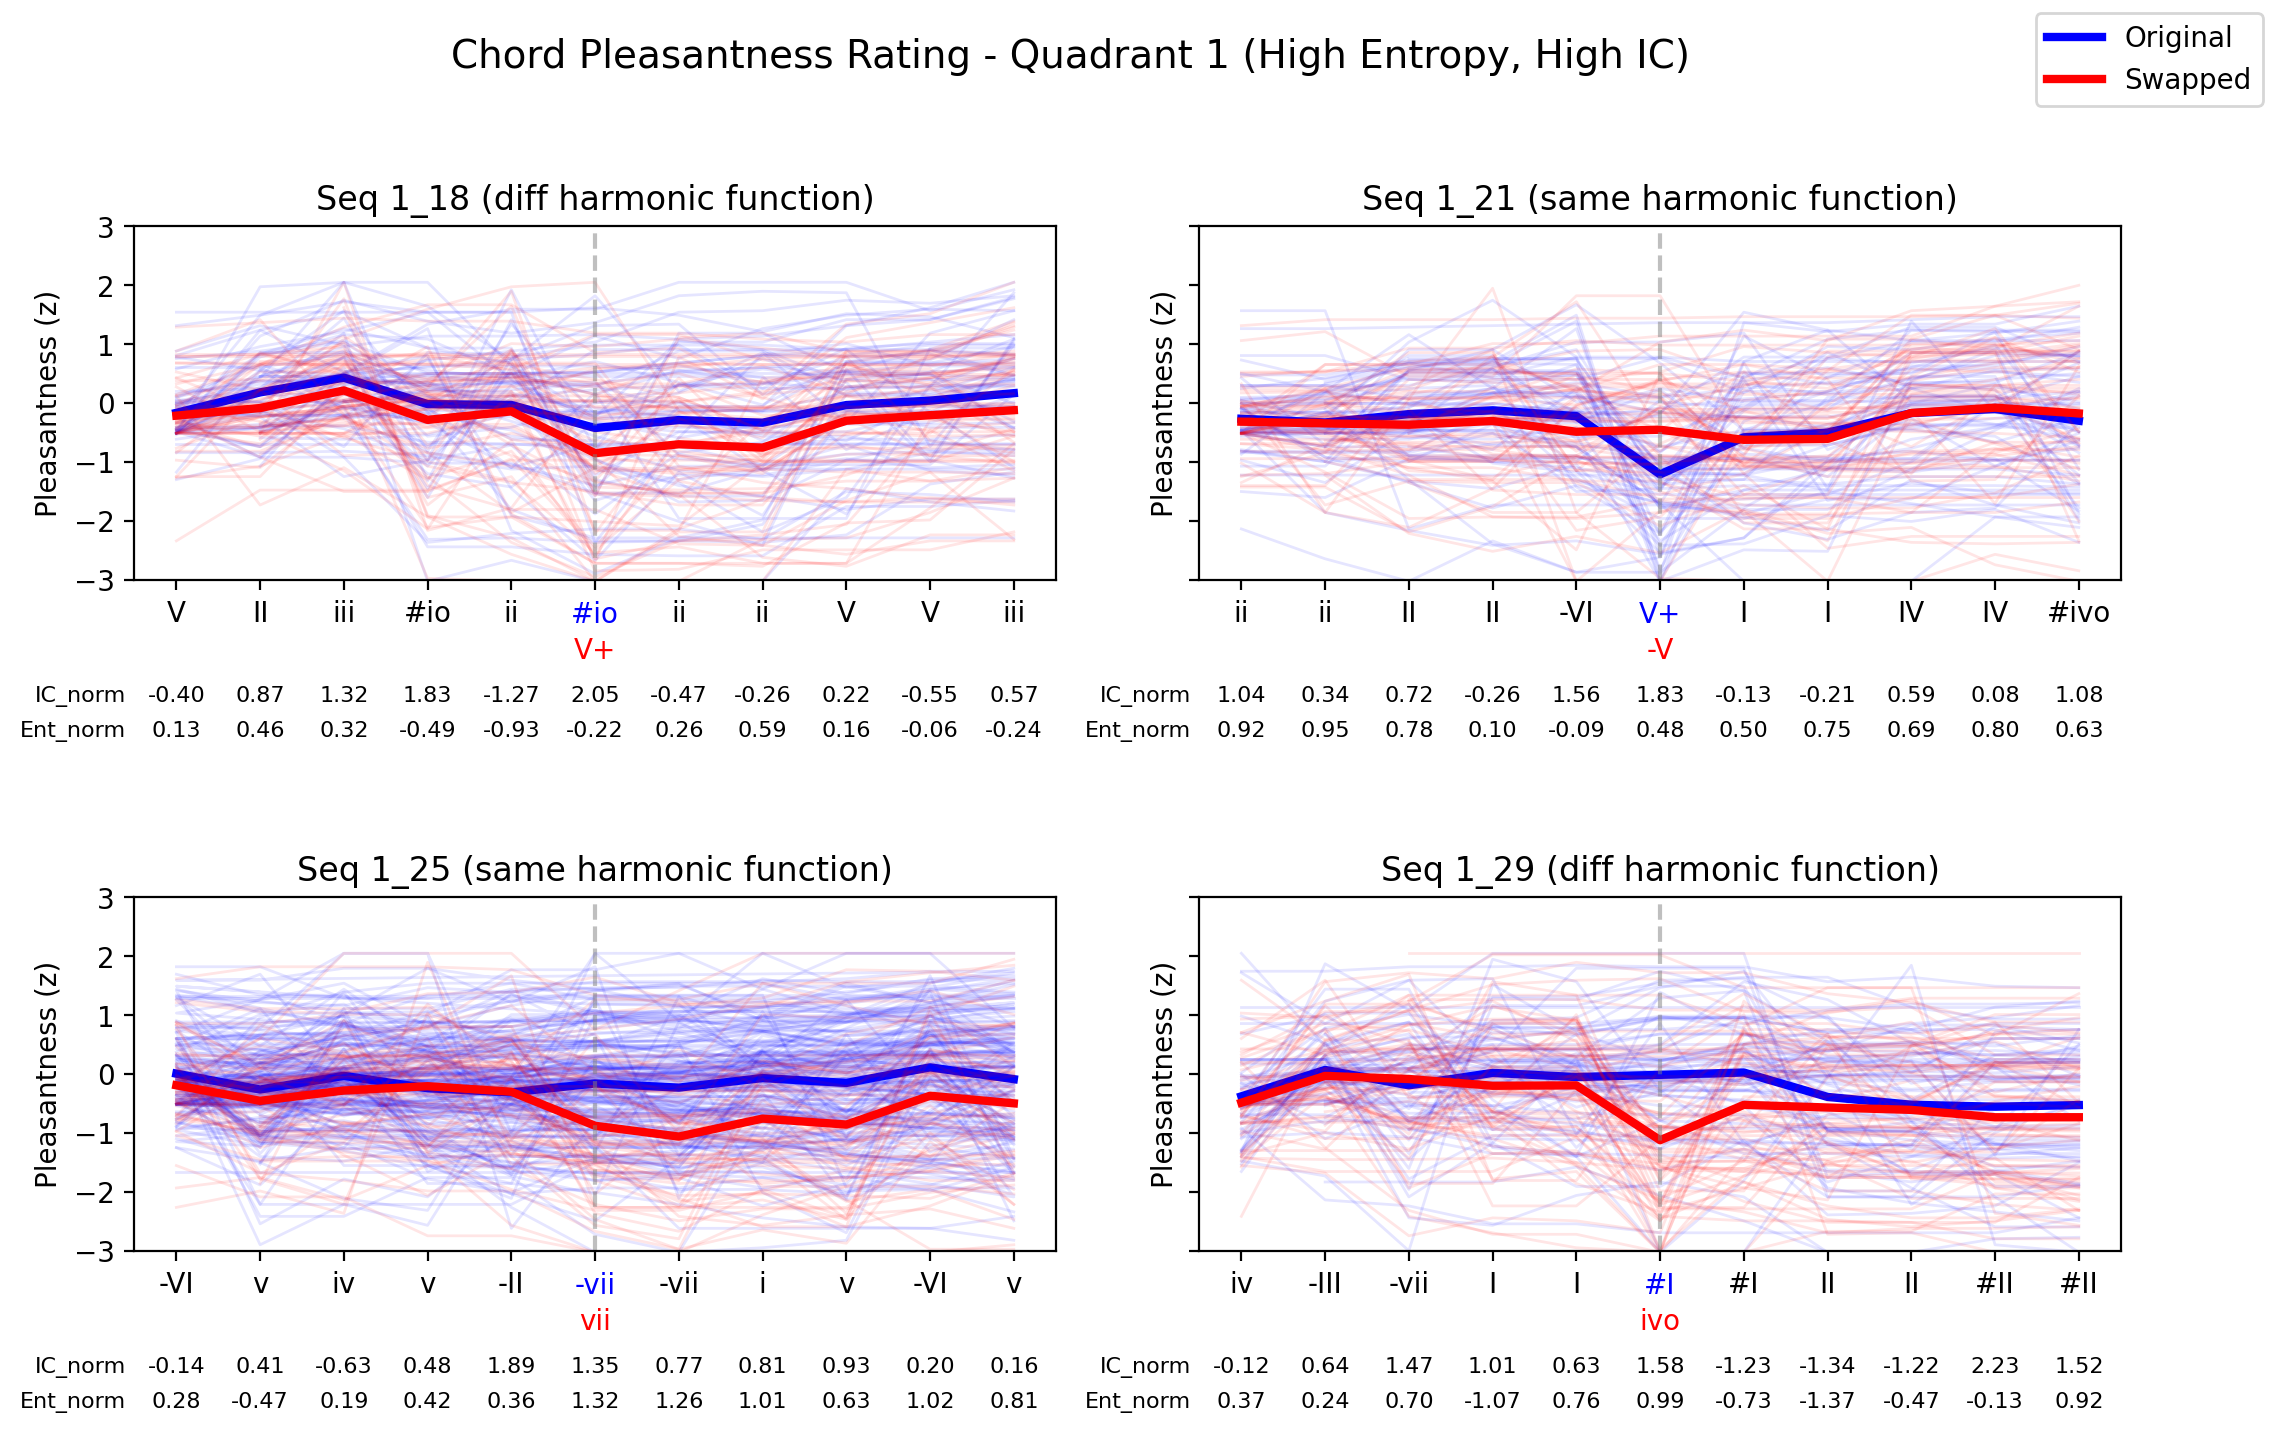

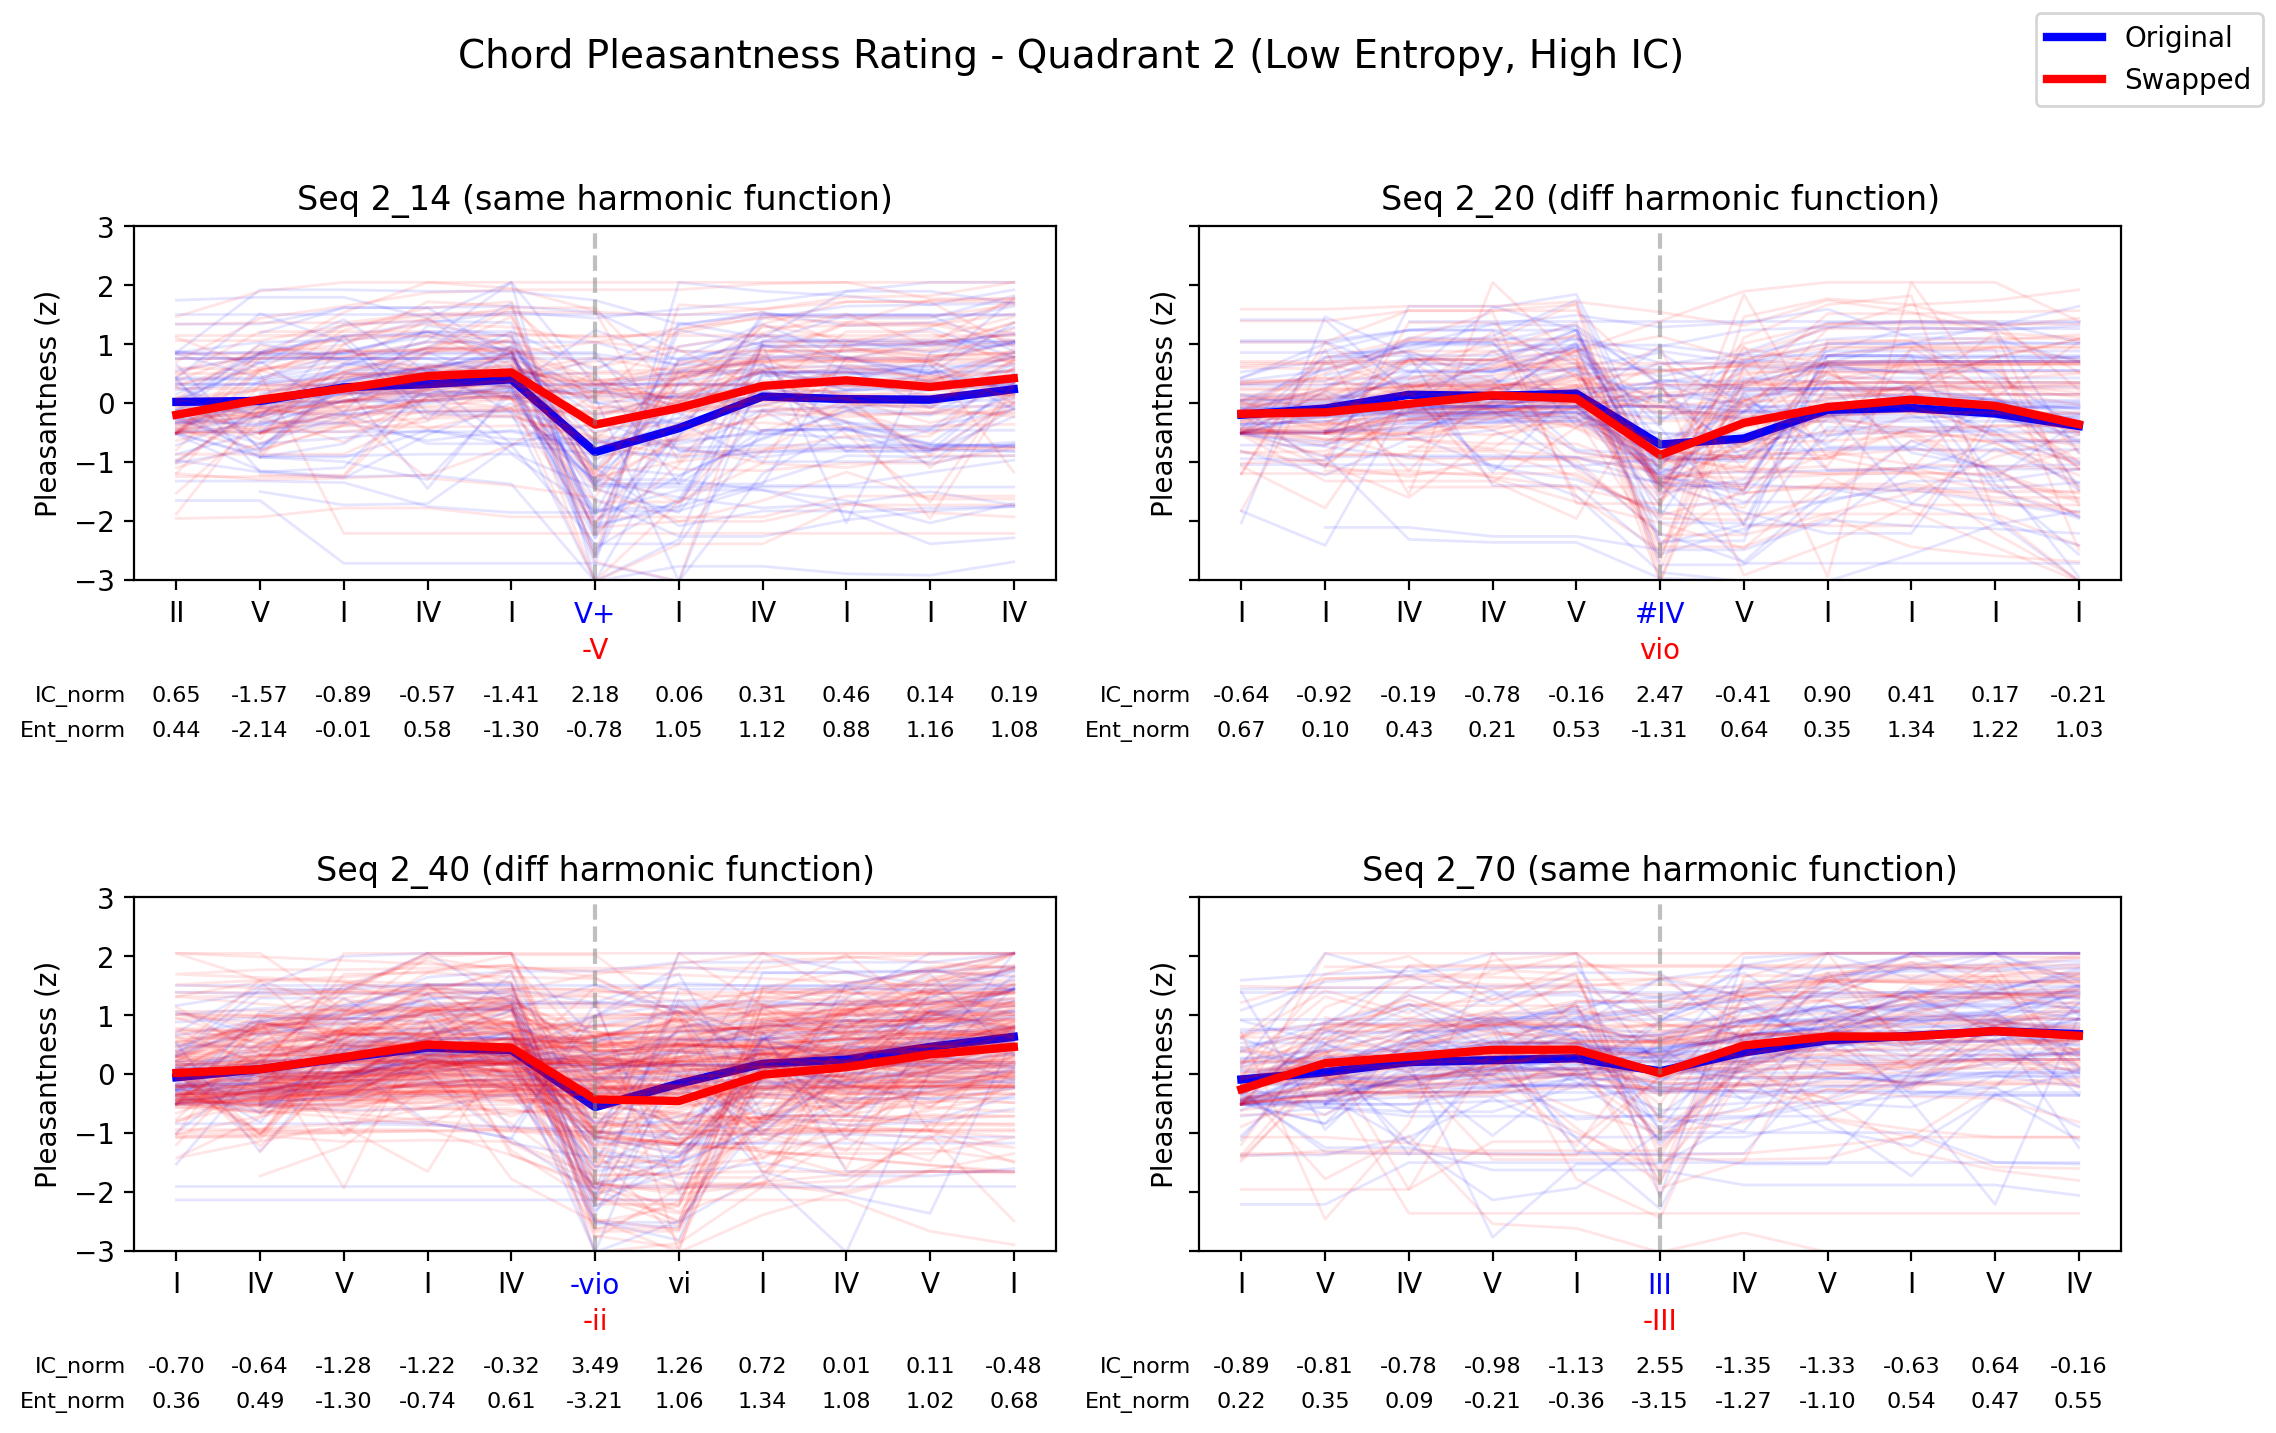

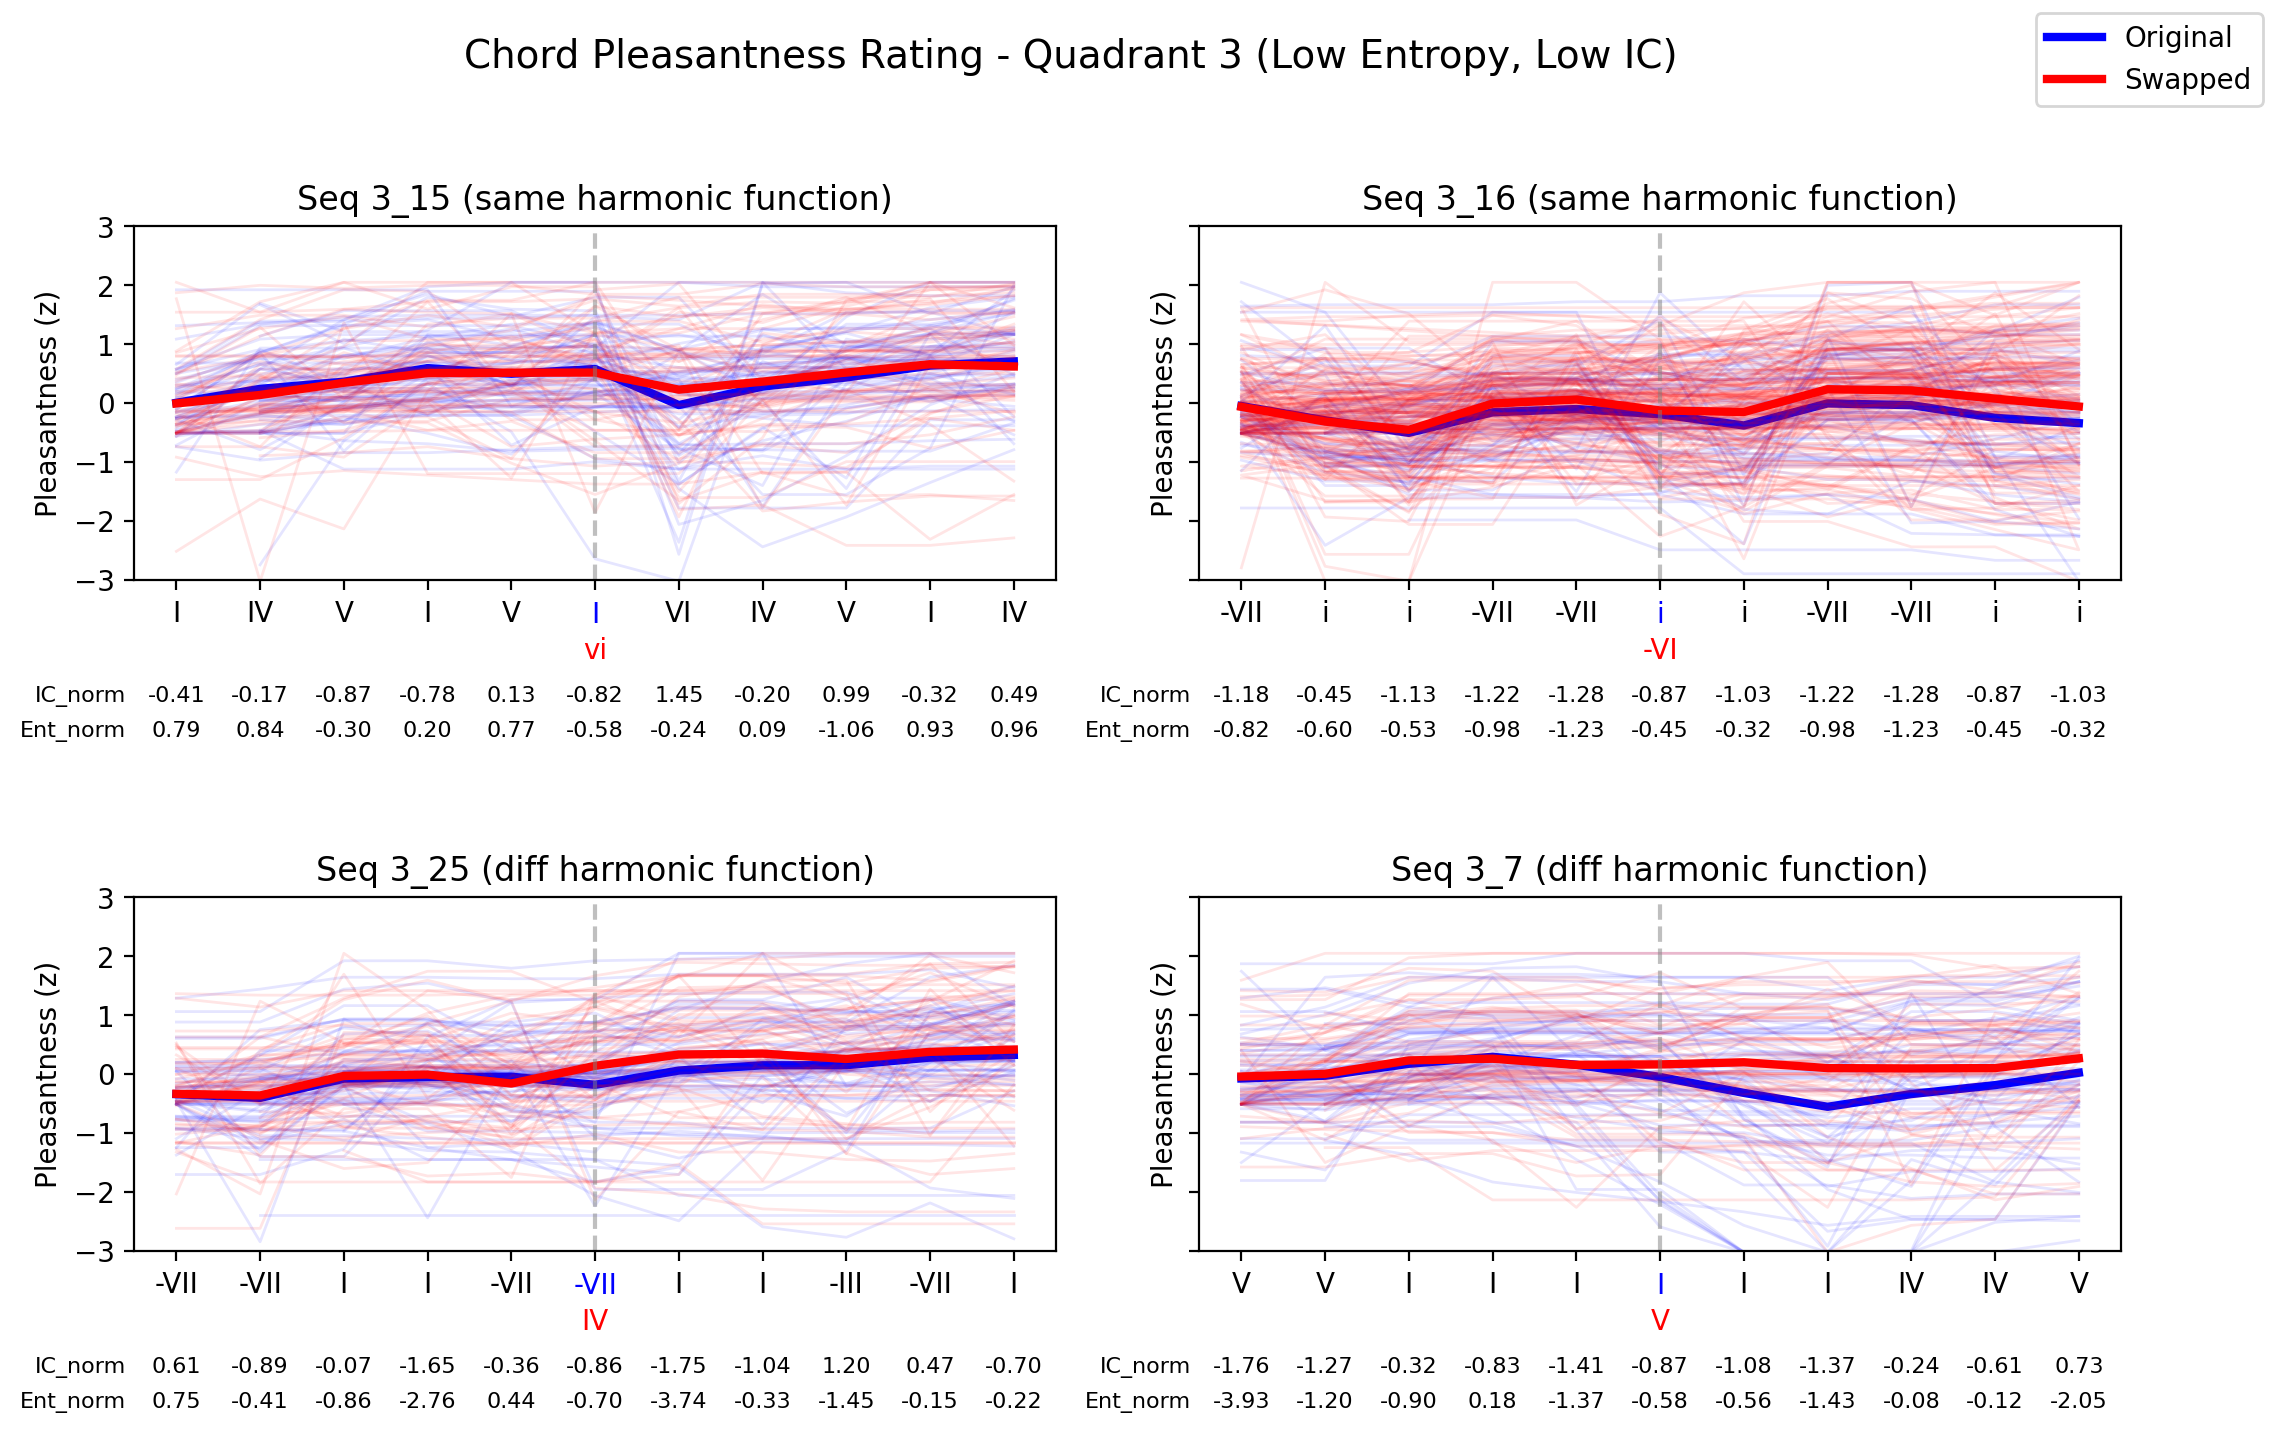

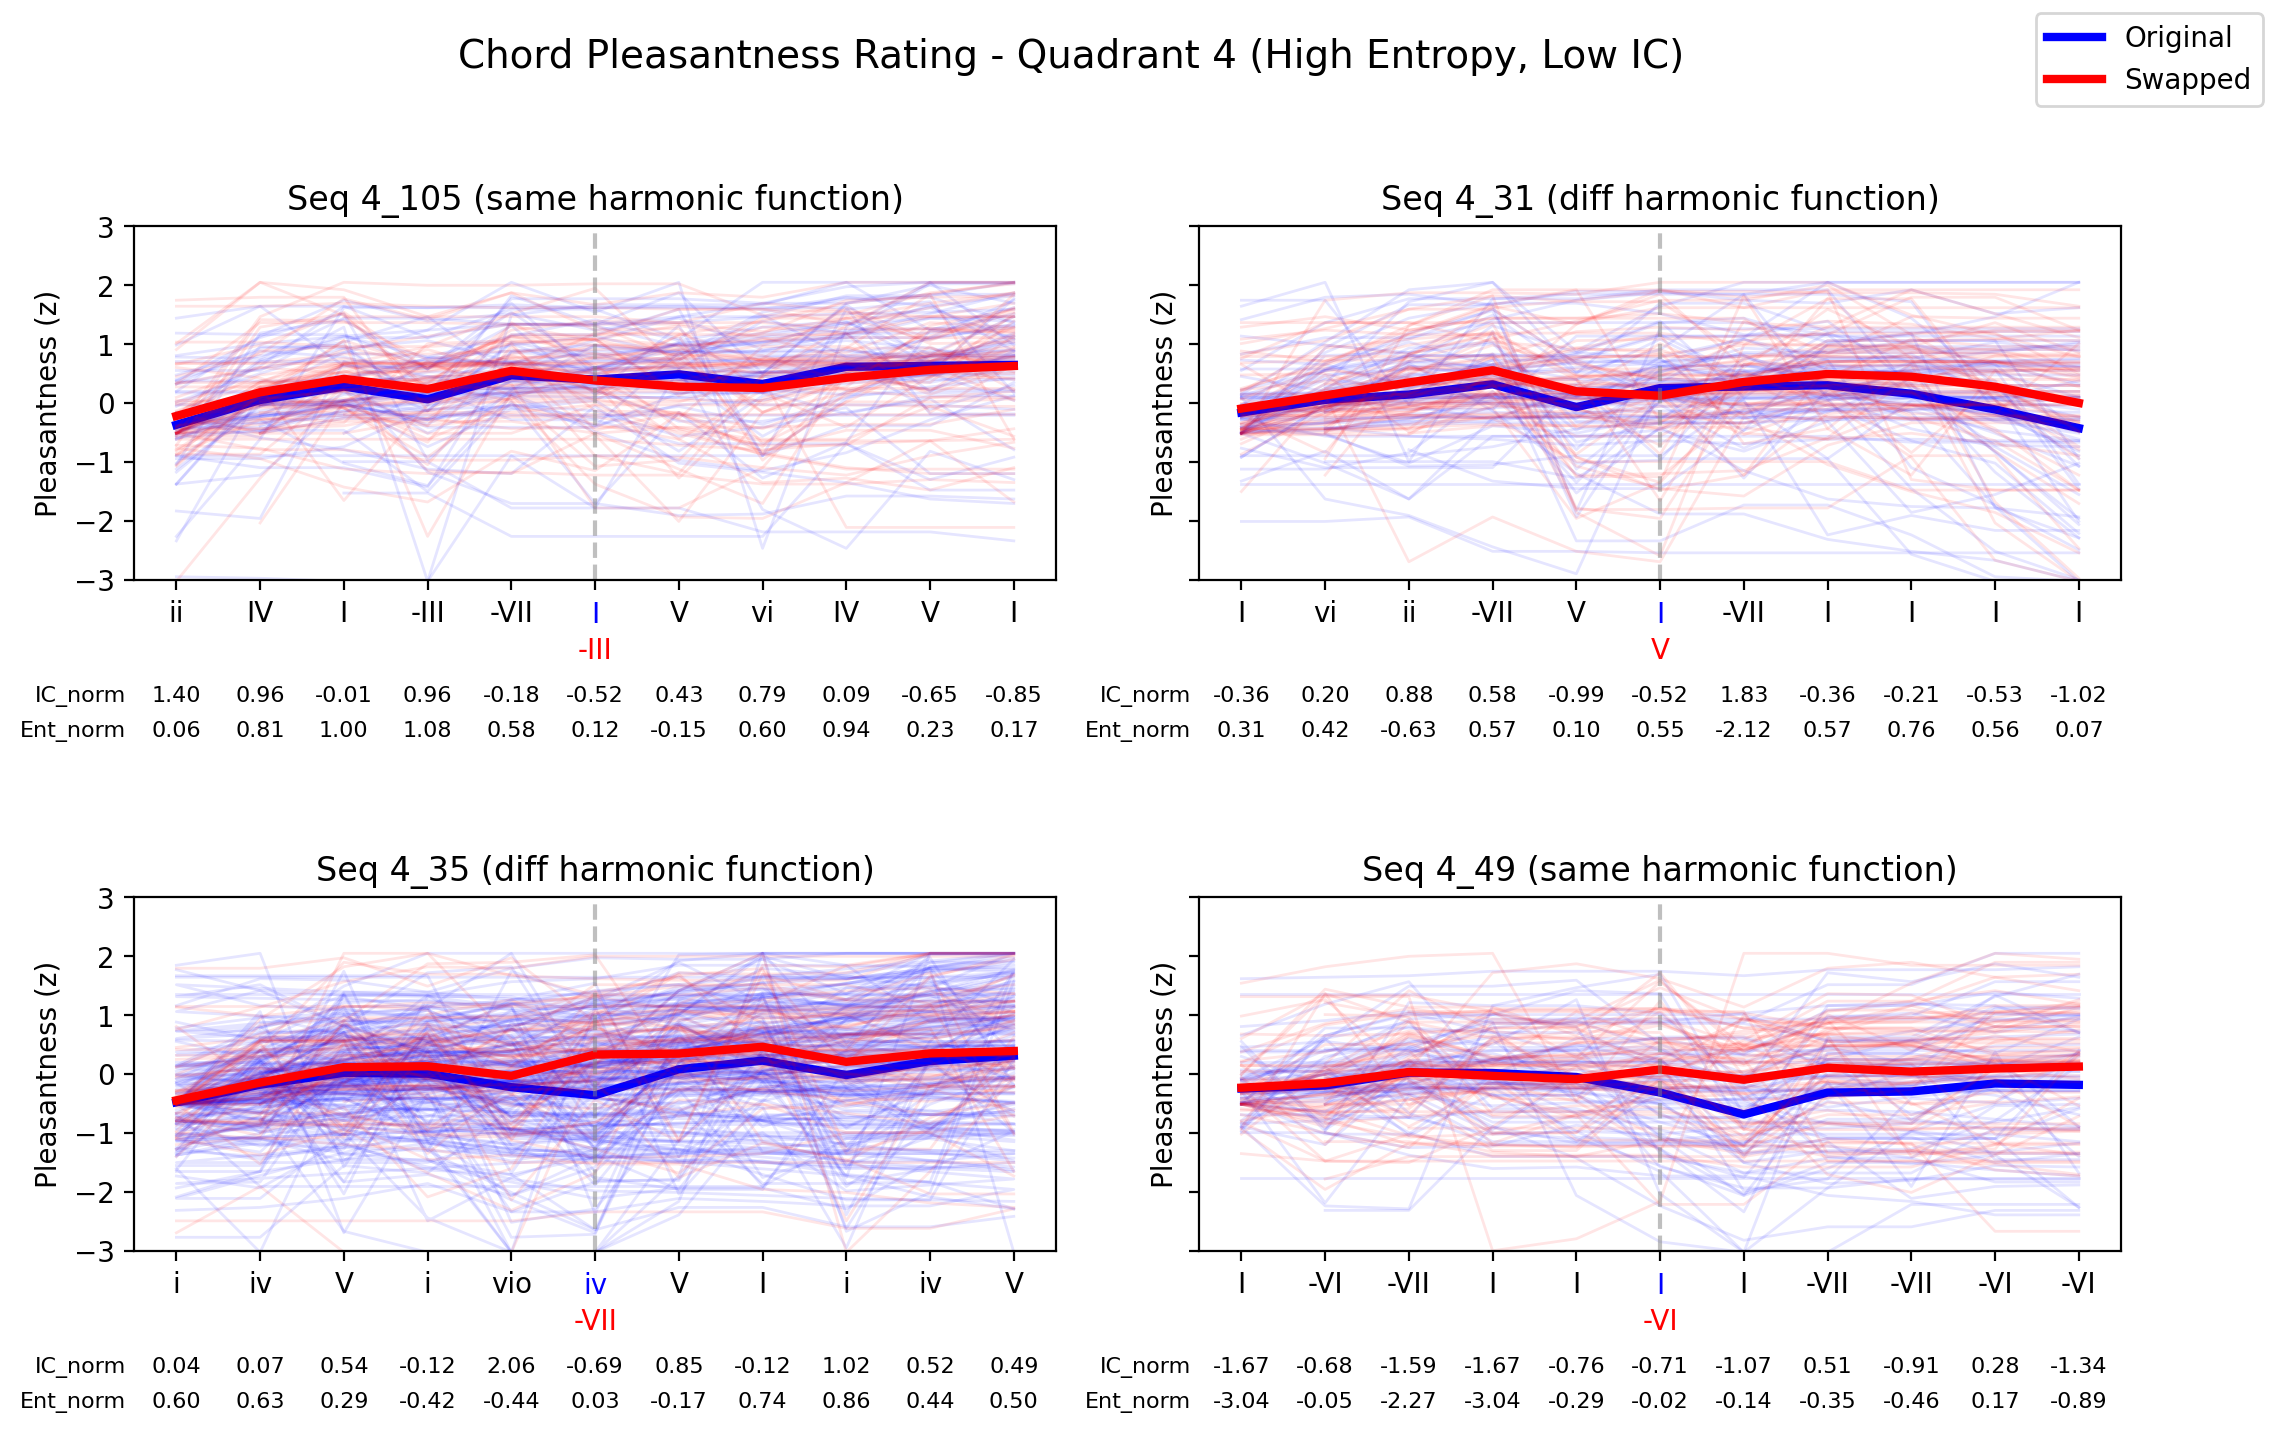

In [108]:
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Load standardized data
data_std = pd.read_csv("./ratings_std_all_participants.csv")


mapping = pd.read_csv(
    "./Stimuli_Question_Mapping.csv"
)

tid = data_std["trial_id"].str.replace("^re", "", regex=True)
parts = tid.str.split("_", expand=True)
data_std["quadrant"] = parts[0]
data_std["sequence_id"] = parts[0] + "_" + parts[1]
data_std["version"] = parts[2]


# Mean traces across participants
mean_traces = (
    data_std
    .groupby(["quadrant","sequence_id","version","chord_index"], as_index=False)
    ["pleasantness"]
    .mean()
)

for quad in sorted(data_std.quadrant.unique()):

    quad_df = data_std[data_std.quadrant == quad]
    quad_mean = mean_traces[mean_traces.quadrant == quad]

    pairs = sorted(quad_df.sequence_id.unique())

    n = len(pairs)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4), sharey=True, dpi=200)
    axes = axes.flatten()
    spacing = 1.5  
    for ax, seq in zip(axes, pairs):

        sub_indiv = quad_df[quad_df.sequence_id == seq]
        sub_mean = quad_mean[quad_mean.sequence_id == seq]

        for version, color in [("O","blue"), ("S","red")]:

            # individual participant traces
            indiv = sub_indiv[sub_indiv.version == version]

            for response_id, psub in indiv.groupby("response"):
                ax.plot(
                    psub.chord_index * spacing,
                    psub.pleasantness,
                    color=color,
                    alpha=0.1,
                    linewidth=1
                )

            # mean trace
            vmean = sub_mean[sub_mean.version == version]

            ax.plot(
                vmean.chord_index * spacing,
                vmean.pleasantness,
                color=color,
                lw=3
            )

        # harmonic function label
        tid = f"{seq}_O"
        harmonic_function = mapping.loc[
            mapping["Data"] == tid, "HarmonicFunction"
        ].iloc[0]

        ax.set_title(f"Seq {seq} ({harmonic_function} harmonic function)")
        ax.set_ylim(-3, 3)

        # mark target chord
        target_chord = 5
        ax.axvline(target_chord * spacing, linestyle="--", color="gray", alpha=0.5)

        # ax.set_xlabel("Chord")
        ax.set_ylabel("Pleasantness (z)")


        # Chord labels
        labels_df = (
            sub_indiv[sub_indiv.version == "O"]
            .sort_values("chord_index")
            .groupby("chord_index", as_index=False)
            .first()[["chord_index", "Symbol", "surprise", "uncertainty"]]
        )
        xticks = [x * spacing for x in labels_df["chord_index"]]
        xticklabels = labels_df["Symbol"].tolist()
        
        idx5 = xticks.index(5 * spacing)
        xticklabels[idx5] = ""  # blank out 5

        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels)

        # get symbols
        label_O = (
            sub_indiv[(sub_indiv.version == "O") & (sub_indiv.chord_index == 5)]
            [["Symbol"]]
            .iloc[0, 0]
        )

        label_S = (
            sub_indiv[(sub_indiv.version == "S") & (sub_indiv.chord_index == 5)]
            [["Symbol"]]
            .iloc[0, 0]
        )

        # draw them centered on tick
        ax.text(
            5 * spacing, -0.06, label_O,
            color="blue",
            ha="center",
            va="top",
            transform=ax.get_xaxis_transform()
        )

        ax.text(
            5 * spacing, -0.16, label_S,
            color="red",
            ha="center",
            va="top",
            transform=ax.get_xaxis_transform()
        )

        # chord info
        ax.text(
            -0.6 * spacing, -0.3, "IC_norm",
            ha="right", va="top",
            fontsize=8,
            transform=ax.get_xaxis_transform()
        )

        ax.text(
            -0.6 * spacing, -0.4, "Ent_norm",
            ha="right", va="top",
            fontsize=8,
            transform=ax.get_xaxis_transform()
        )
        for _, row in labels_df.iterrows():
            x = row["chord_index"]
            ax.text(x * spacing, -0.3, f"{row['surprise']:.2f}",
                    ha="center", va="top", fontsize=8,
                    transform=ax.get_xaxis_transform())
            ax.text(x * spacing, -0.4, f"{row['uncertainty']:.2f}",
                    ha="center", va="top", fontsize=8,
                    transform=ax.get_xaxis_transform())

    # remove empty panels
    for ax in axes[len(pairs):]:
        ax.axis("off")

    legend_lines = [
        Line2D([0],[0],color="blue",lw=3),
        Line2D([0],[0],color="red",lw=3)
    ]

    fig.legend(legend_lines, ["Original","Swapped"], loc="upper right")

    
    match int(quad):
        case 1:
            quadrant_text = "High Entropy, High IC"
        case 2:
            quadrant_text = "Low Entropy, High IC"
        case 3:
            quadrant_text = "Low Entropy, Low IC"
        case 4:
            quadrant_text = "High Entropy, Low IC"
        case _:
            quadrant_text = ""

    fig.suptitle(
        f"Chord Pleasantness Rating - Quadrant {quad} ({quadrant_text})",
        fontsize=14
    )

    plt.tight_layout(rect=[0.05,0.05,0.95,0.95])
    plt.show()